# 🇸🇬 Singapore Business Formation Analysis (1990–2026)

**Data source:** [data.gov.sg](https://data.gov.sg) — Department of Statistics Singapore  
**Period covered:** January 1990 – March 2026  
**Industries:** 14 sectors  
**Total records:** 6,090 monthly data points

---

## Business Questions
1. Which industries recovered strongest post-COVID?
2. What was the real COVID-19 impact — and which industries defied expectations?
3. Where is Singapore's economy heading in 2025–2026?
4. What are the 35-year structural trends?

---


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
    "figure.dpi":        130,
})

EXCLUDE = ["Total", "Others"]
FOCUS_INDUSTRIES = [
    "Information & Communications",
    "Finance & Insurance",
    "Professional Services",
    "Transportation & Storage",
    "Retail Trade",
    "Food & Beverage Services",
    "Construction",
    "Manufacturing",
]
PALETTE = {
    "Information & Communications":   "#2563EB",
    "Finance & Insurance":            "#7C3AED",
    "Professional Services":          "#059669",
    "Transportation & Storage":       "#DC2626",
    "Retail Trade":                   "#D97706",
    "Food & Beverage Services":       "#DB2777",
    "Construction":                   "#0891B2",
    "Manufacturing":                  "#65A30D",
}
print("Libraries loaded.")

In [ ]:
df = pd.read_csv("cleaned_business_entity_formations_long.csv")
df["date"]  = pd.to_datetime(df["date"])
df["year"]  = df["date"].dt.year
df["month"] = df["date"].dt.month

df_clean    = df[~df["DataSeries"].isin(EXCLUDE)].copy()
df_baseline = df_clean[df_clean["year"].isin([2017, 2018, 2019])]
df_recovery = df_clean[df_clean["date"] >= "2022-01-01"]
df_latest   = df_clean[df_clean["date"] >= "2025-01-01"]
df_focus    = df_clean[df_clean["DataSeries"].isin(FOCUS_INDUSTRIES)]

print(f"Rows    : {len(df_clean):,}")
print(f"Period  : {df_clean['date'].min().date()} → {df_clean['date'].max().date()}")
print(f"Industries: {df_clean['DataSeries'].nunique()}")
df_clean.head(3)

---
## Chart 1 — Post-COVID Recovery by Industry
Compare 2022–2026 monthly average vs the 2017–2019 pre-COVID baseline.


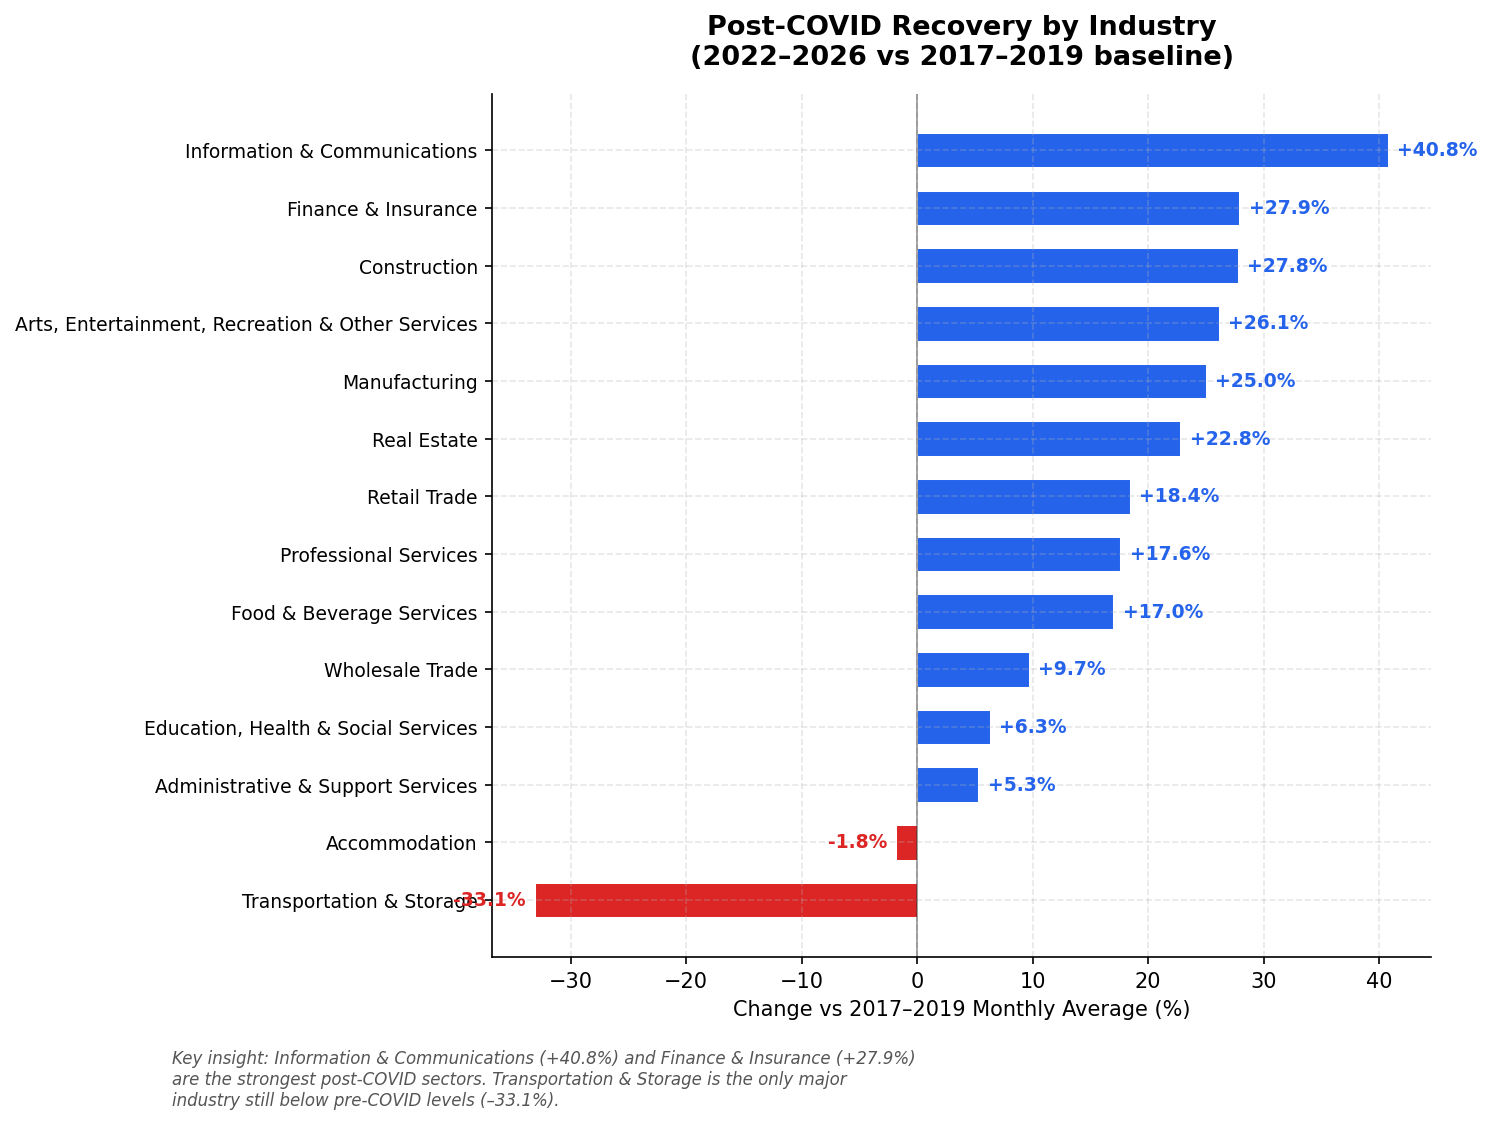

In [ ]:
baseline_avg = df_baseline.groupby("DataSeries")["value"].mean()
recovery_avg = df_recovery.groupby("DataSeries")["value"].mean()
recovery_df  = pd.DataFrame({"baseline": baseline_avg, "recovery": recovery_avg}).dropna()
recovery_df["pct_change"] = ((recovery_df["recovery"] - recovery_df["baseline"])
                               / recovery_df["baseline"] * 100).round(1)
recovery_df = recovery_df.sort_values("pct_change", ascending=True)

colors = ["#DC2626" if x < 0 else "#2563EB" for x in recovery_df["pct_change"]]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(recovery_df.index, recovery_df["pct_change"],
               color=colors, height=0.6, edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, recovery_df["pct_change"]):
    x_pos = val + 0.8 if val >= 0 else val - 0.8
    ha    = "left" if val >= 0 else "right"
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f"{val:+.1f}%", va="center", ha=ha, fontsize=9,
            fontweight="bold", color="#DC2626" if val < 0 else "#2563EB")
ax.axvline(0, color="black", linewidth=0.8, alpha=0.4)
ax.set_xlabel("Change vs 2017–2019 Monthly Average (%)", fontsize=10)
ax.set_title("Post-COVID Recovery by Industry
(2022–2026 vs 2017–2019 baseline)",
             fontsize=13, fontweight="bold", pad=14)
ax.tick_params(axis="y", labelsize=9)
fig.text(0.12, -0.04,
    "Key insight: Information & Communications (+40.8%) and Finance & Insurance (+27.9%) "
    "are the strongest post-COVID sectors.
Transportation & Storage is the only major industry "
    "still below pre-COVID levels (–33.1%).",
    fontsize=8, color="#555555", style="italic")
plt.tight_layout()
plt.show()

---
## Chart 2 — 35-Year Structural Trends (1990–2026)
Annual business formations across 8 key industries. Key crisis events annotated.


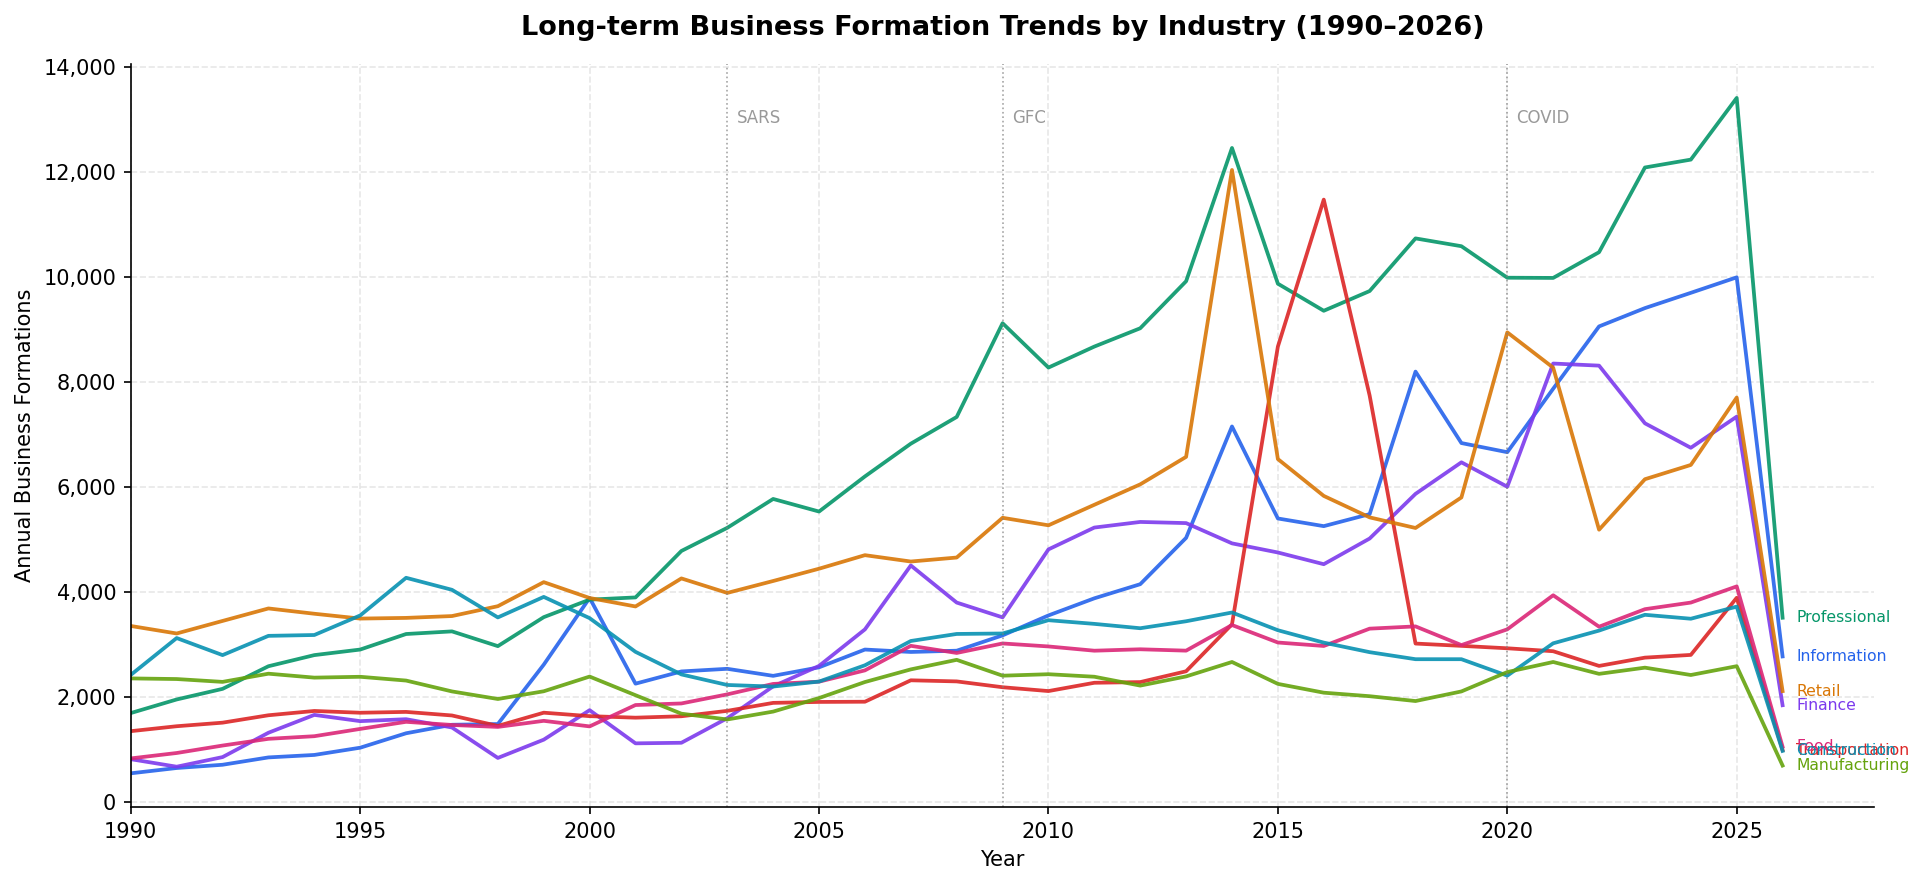

In [ ]:
df_annual = (df_focus.groupby(["DataSeries", "year"])["value"]
             .sum().reset_index())

fig, ax = plt.subplots(figsize=(13, 6))
for industry in FOCUS_INDUSTRIES:
    d = df_annual[df_annual["DataSeries"] == industry]
    ax.plot(d["year"], d["value"],
            label=industry, color=PALETTE[industry], linewidth=1.8, alpha=0.9)
    last = d.iloc[-1]
    ax.text(last["year"] + 0.3, last["value"],
            industry.split(" ")[0], fontsize=7.5,
            color=PALETTE[industry], va="center")

for year, label in [(2003, "SARS"), (2009, "GFC"), (2020, "COVID")]:
    ax.axvline(year, color="gray", linewidth=0.8, linestyle=":", alpha=0.7)
    ax.text(year + 0.2, ax.get_ylim()[1] * 0.9, label, fontsize=8, color="gray")

ax.set_xlabel("Year", fontsize=10)
ax.set_ylabel("Annual Business Formations", fontsize=10)
ax.set_title("Long-term Business Formation Trends by Industry (1990–2026)",
             fontsize=13, fontweight="bold", pad=14)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xlim(1990, 2028)
plt.tight_layout()
plt.show()

---
## Chart 3 — The COVID Surprise: 2020 vs 2019
Not all industries were hurt. Some counter-intuitive winners emerged.


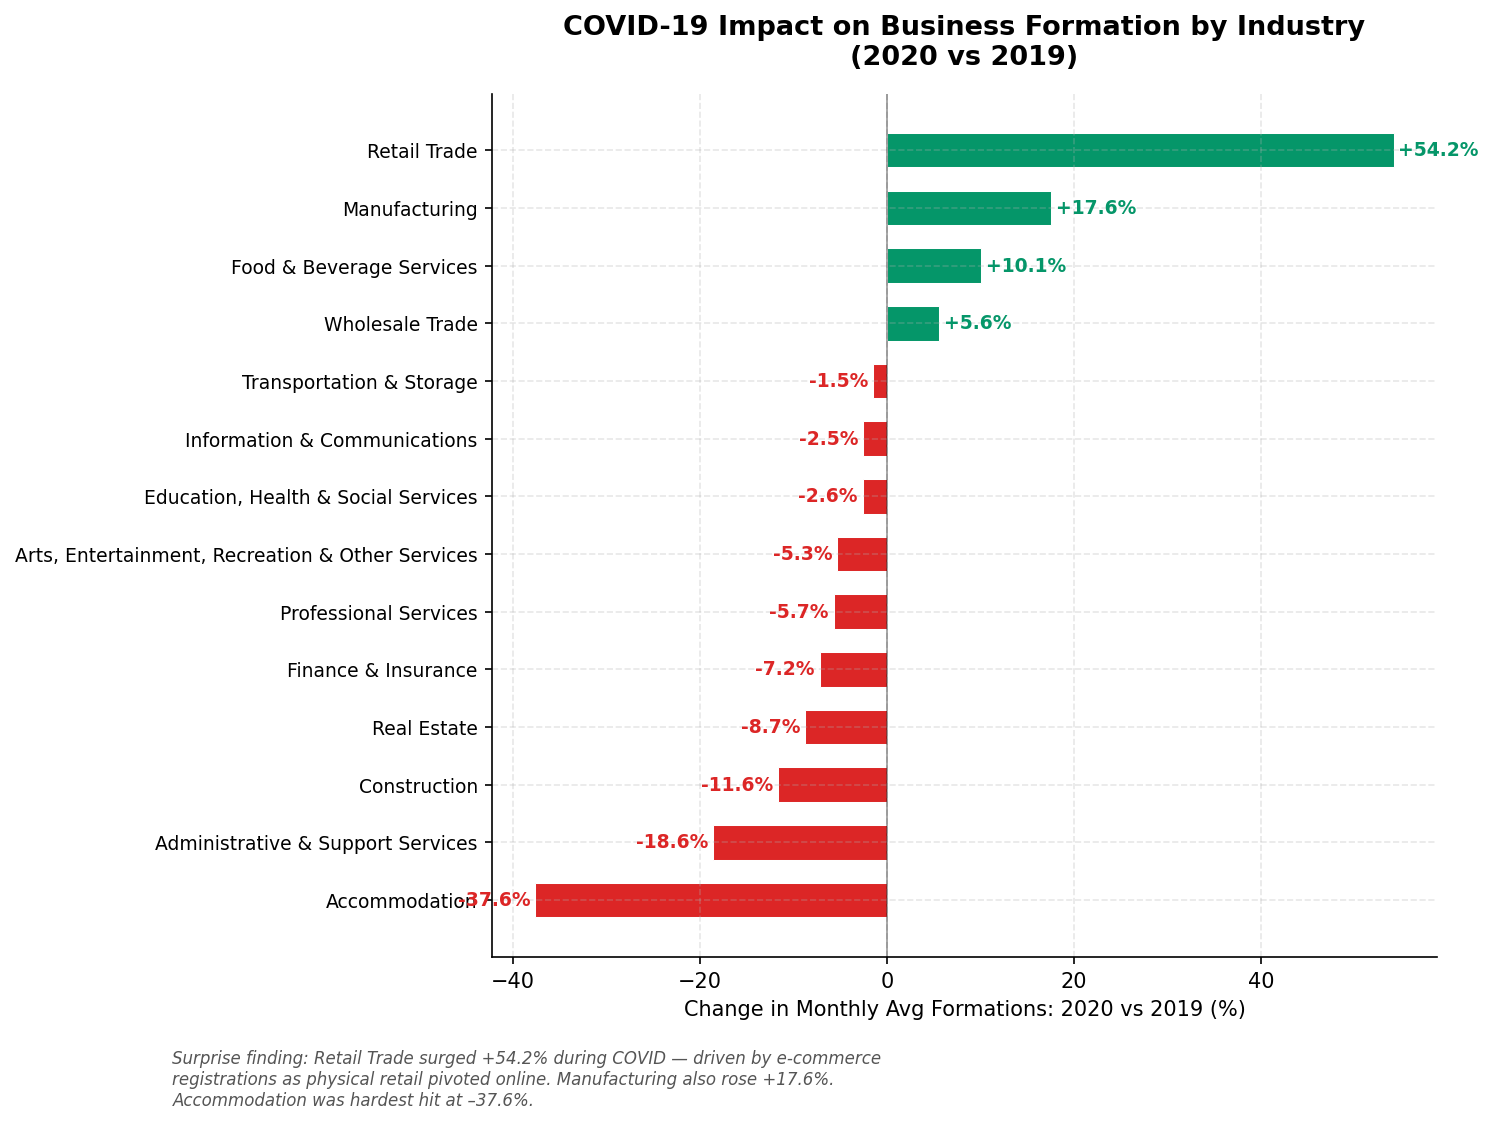

In [ ]:
pre_covid = df_clean[df_clean["year"] == 2019].groupby("DataSeries")["value"].mean()
dur_covid = df_clean[df_clean["year"] == 2020].groupby("DataSeries")["value"].mean()
covid_df  = pd.DataFrame({"2019": pre_covid, "2020": dur_covid}).dropna()
covid_df["impact_pct"] = ((covid_df["2020"] - covid_df["2019"])
                            / covid_df["2019"] * 100).round(1)
covid_df = covid_df.sort_values("impact_pct", ascending=True)

colors_c = ["#DC2626" if x < 0 else "#059669" for x in covid_df["impact_pct"]]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(covid_df.index, covid_df["impact_pct"],
               color=colors_c, height=0.6, edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, covid_df["impact_pct"]):
    x_pos = val + 0.5 if val >= 0 else val - 0.5
    ha    = "left" if val >= 0 else "right"
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f"{val:+.1f}%", va="center", ha=ha, fontsize=9,
            fontweight="bold", color="#059669" if val >= 0 else "#DC2626")
ax.axvline(0, color="black", linewidth=0.8, alpha=0.4)
ax.set_xlabel("Change in Monthly Avg Formations: 2020 vs 2019 (%)", fontsize=10)
ax.set_title("COVID-19 Impact on Business Formation by Industry
(2020 vs 2019)",
             fontsize=13, fontweight="bold", pad=14)
ax.tick_params(axis="y", labelsize=9)
fig.text(0.12, -0.04,
    "Surprise: Retail Trade surged +54.2% during COVID — driven by e-commerce registrations. "
    "Manufacturing also rose +17.6%.
Accommodation was hardest hit at –37.6%.",
    fontsize=8, color="#555555", style="italic")
plt.tight_layout()
plt.show()

---
## Chart 4 — 2025–2026 Momentum: Where is Singapore Heading?
Current monthly business formation rates — the clearest signal of where hiring demand will grow.


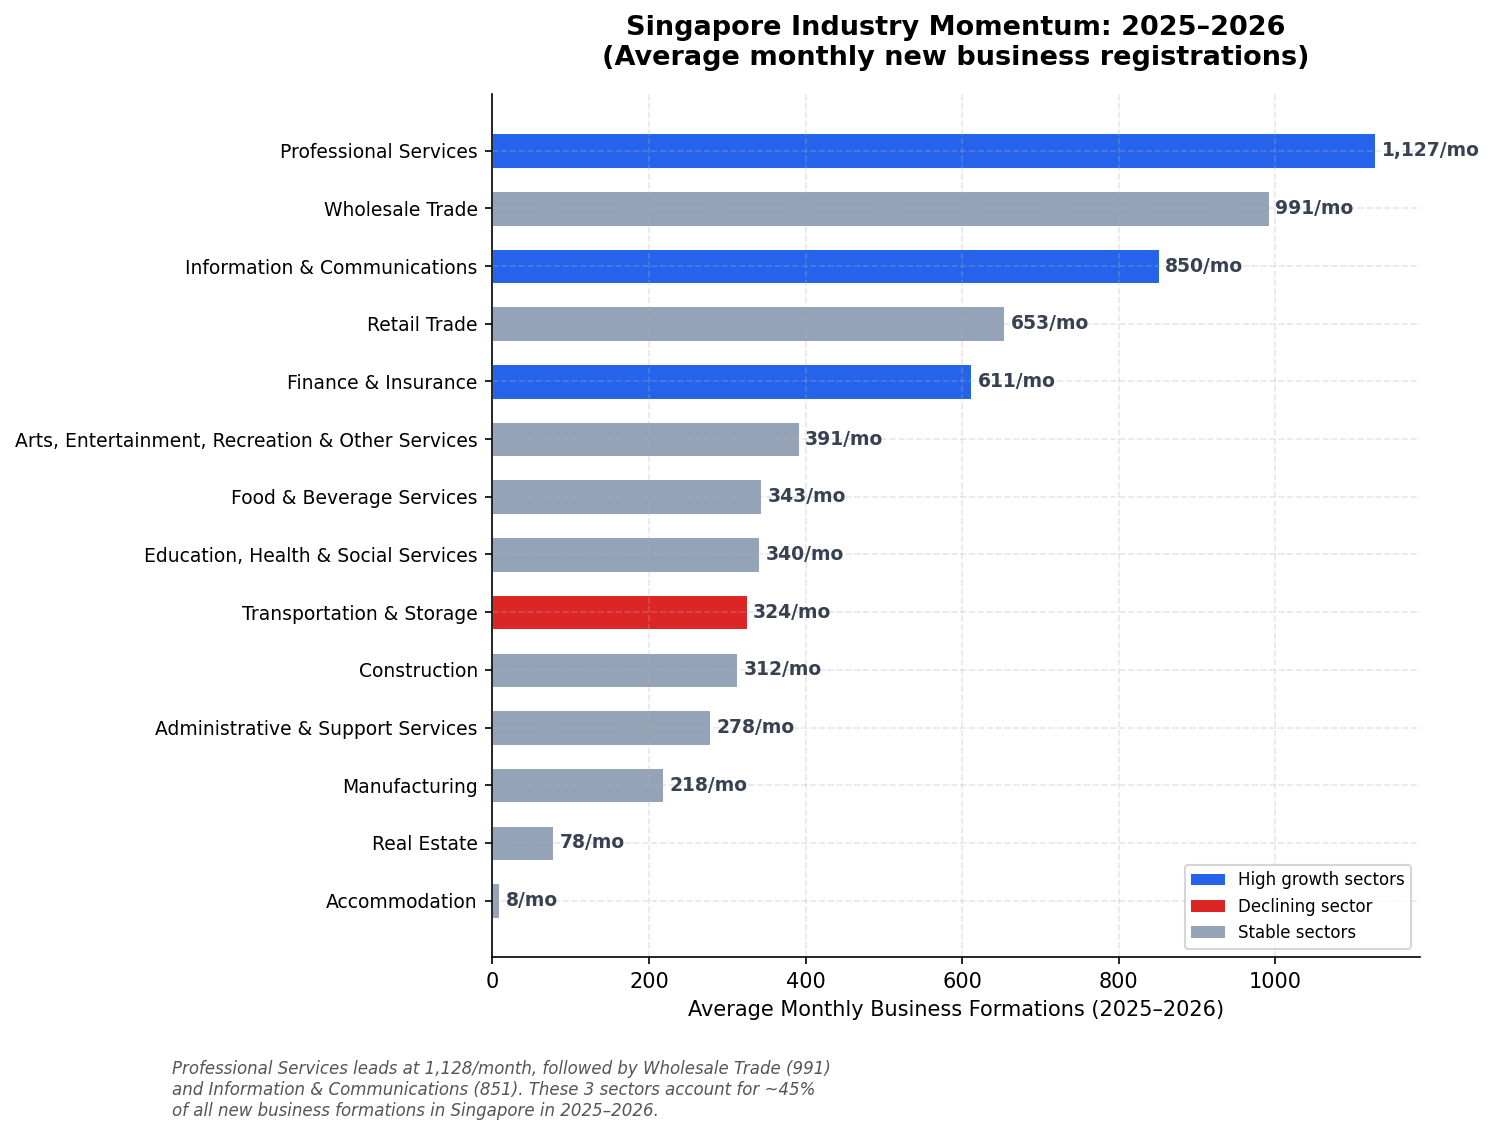

In [ ]:
from matplotlib.patches import Patch

latest_avg = (df_latest.groupby("DataSeries")["value"]
              .mean().sort_values(ascending=True))

bar_colors = []
for ind in latest_avg.index:
    if ind in ["Information & Communications", "Finance & Insurance", "Professional Services"]:
        bar_colors.append("#2563EB")
    elif ind == "Transportation & Storage":
        bar_colors.append("#DC2626")
    else:
        bar_colors.append("#94A3B8")

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(latest_avg.index, latest_avg.values,
               color=bar_colors, height=0.6, edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, latest_avg.values):
    ax.text(val + 8, bar.get_y() + bar.get_height() / 2,
            f"{int(val):,}/mo", va="center", fontsize=9,
            fontweight="bold", color="#374151")
ax.set_xlabel("Average Monthly Business Formations (2025–2026)", fontsize=10)
ax.set_title("Singapore Industry Momentum: 2025–2026
(Average monthly new business registrations)",
             fontsize=13, fontweight="bold", pad=14)
ax.tick_params(axis="y", labelsize=9)
legend_elements = [
    Patch(facecolor="#2563EB", label="High-growth sectors"),
    Patch(facecolor="#DC2626", label="Declining sector"),
    Patch(facecolor="#94A3B8", label="Stable sectors"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=8, framealpha=0.8)
fig.text(0.12, -0.04,
    "Professional Services leads at 1,128/month, followed by Wholesale Trade (991) "
    "and Information & Communications (851).
These 3 sectors account for ~45% of all "
    "new business formations in Singapore in 2025–2026.",
    fontsize=8, color="#555555", style="italic")
plt.tight_layout()
plt.show()

---
## Executive Summary

| Industry | Pre-COVID avg/mo | 2025–26 avg/mo | Change |
|---|---|---|---|
| Information & Communications | 570 | 851 | **+40.8%** |
| Finance & Insurance | 482 | 612 | **+27.9%** |
| Construction | 230 | 312 | +27.8% |
| Manufacturing | 168 | 218 | +25.0% |
| Professional Services | 862 | 1,128 | +17.6% |
| Retail Trade | 456 | 654 | +18.4% |
| Accommodation | 8 | 9 | –1.8% |
| Transportation & Storage | 381 | 325 | **–33.1%** |

### Key Takeaways

1. **Information & Communications is Singapore's fastest-growing sector** — +40.8% post-COVID. 851 new businesses/month signals sustained demand for tech, data, and digital talent.

2. **Finance & Insurance is accelerating** — +27.9% post-COVID, driven by Fintech and digital banking. MAS's regulatory sandbox continues to attract new entrants.

3. **Transportation & Storage faces structural decline** — the –33.1% drop is not a COVID story. Platform consolidation (Grab, Gojek, Lalamove) has permanently reduced the number of independent operators.

4. **Retail was transformed, not destroyed** — the +54.2% COVID surge was an e-commerce creation event. New baseline is now +18.4% above pre-COVID, reflecting a permanent structural shift online.

5. **Professional Services is the largest sector by volume** — 1,128 new registrations/month. Every growing industry needs legal, consulting, and accounting support.

---
*Data: Singapore Department of Statistics via data.gov.sg | Analysis period: 1990–2026*
